In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.decomposition import PCA

from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import scipy.stats as stats

In [3]:
data=load_breast_cancer()
x=data.data
y=data.target

print("Dataset Shape:",x.shape)

Dataset Shape: (569, 30)


In [5]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
#For Gaussian NB -- standard scaleing
scaler_std=StandardScaler()
X_train_std=scaler_std.fit_transform(X_train)
X_test_std=scaler_std.transform(X_test)

#For multinomial NB -- requires non negative values
scaler_mm=MinMaxScaler()
X_train_mm=scaler_mm.fit_transform(X_train)
X_test_mm=scaler_mm.transform(X_test)

#For Bernoulli NB -- Binary features
binarizer=Binarizer(threshold=0.0)
X_train_bin=binarizer.fit_transform(X_train_mm)
X_test_bin=binarizer.transform(X_test_mm)

In [10]:
#Gaussian NB
gnb=GaussianNB()
gnb.fit(X_train_std,y_train)
y_predd_gnb=gnb.predict(X_test_std)
y_prob_gnb=gnb.predict_proba(X_test_std)[:,1]

#multinomial NB
mnb=MultinomialNB()
mnb.fit(X_train_mm,y_train)
y_predd_mnb=mnb.predict(X_test_mm)
y_prob_mnb=mnb.predict_proba(X_test_mm)[:,1]

#Bernoulli NB
bnb=BernoulliNB()
bnb.fit(X_train_bin,y_train)
y_predd_bnb=bnb.predict(X_test_bin)
y_prob_bnb=bnb.predict_proba(X_test_bin)[:,1]

In [11]:
param_grid={
    'var_smoothing':np.logspace(-12,-6,50)
}
gnb_grid=GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)
gnb_grid.fit(X_train_std,y_train)

print("Best Param:",gnb_grid.best_params_)

gnb_best=gnb_grid.best_estimator_
y_predd_gnb_best=gnb_best.predict(X_test_std)

Best Param: {'var_smoothing': 1e-12}


In [12]:
def evalute_model(y_test,y_pred,y_prob,model_name):
    print(f'\n======{model_name}=======')
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print("\nConfusion Matrix:",confusion_matrix(y_test,y_pred))
    print("\nClassification Report:",classification_report(y_test,y_pred))

    fpr,tpr,_=roc_curve(y_test,y_pred)
    roc_auc=auc(fpr,tpr)

    plt.figure()
    plt.plot(fpr,tpr,label="AUC = %.2f" % roc_auc)
    plt.plot([0,1],[0,1])
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{model_name} ROC curve")
    plt.legend()
    plt.show()


======Gaussian=======
Accuracy: 0.9649122807017544

Confusion Matrix: [[40  3]
 [ 1 70]]

Classification Report:               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



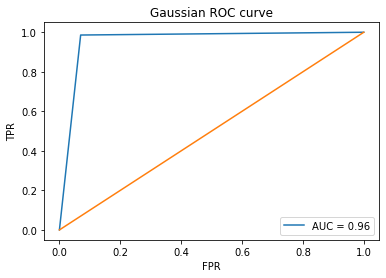

In [13]:
evalute_model(y_test,y_predd_gnb,y_prob_gnb,"Gaussian")


======Multinomial=======
Accuracy: 0.8508771929824561

Confusion Matrix: [[26 17]
 [ 0 71]]

Classification Report:               precision    recall  f1-score   support

           0       1.00      0.60      0.75        43
           1       0.81      1.00      0.89        71

    accuracy                           0.85       114
   macro avg       0.90      0.80      0.82       114
weighted avg       0.88      0.85      0.84       114



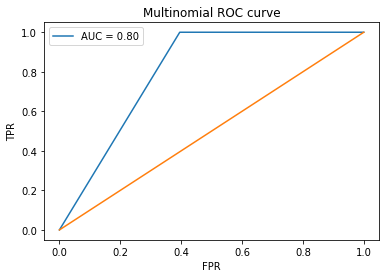

In [14]:
evalute_model(y_test,y_predd_mnb,y_prob_mnb,"Multinomial")


======Bernoulli=======
Accuracy: 0.6228070175438597

Confusion Matrix: [[ 0 43]
 [ 0 71]]

Classification Report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



c:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\ProgramData\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


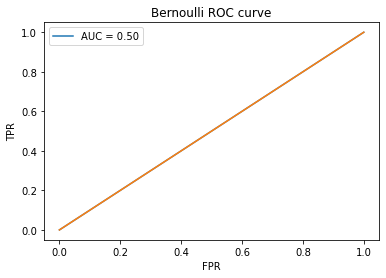

In [15]:
evalute_model(y_test,y_predd_bnb,y_prob_bnb,"Bernoulli")


======Tuned Gaussian=======
Accuracy: 0.9649122807017544

Confusion Matrix: [[40  3]
 [ 1 70]]

Classification Report:               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



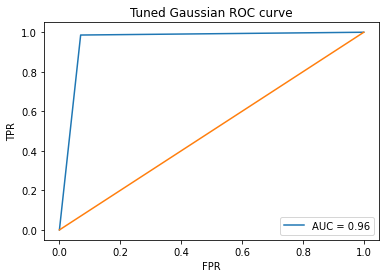

In [16]:
evalute_model(y_test,y_predd_gnb_best,y_prob_gnb,"Tuned Gaussian")

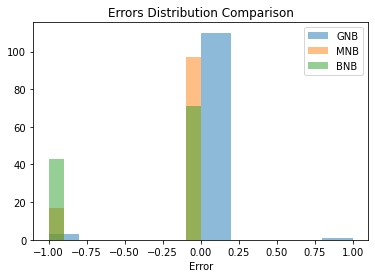

In [17]:
errors={
    "GNB":y_test - y_predd_gnb,
    "MNB":y_test - y_predd_mnb,
    "BNB":y_test - y_predd_bnb,
}

plt.figure()

for key,val in errors.items():
    plt.hist(val,alpha=0.5,label=key)

plt.legend()
plt.title("Errors Distribution Comparison")
plt.xlabel("Error")
plt.show()

No handles with labels found to put in legend.


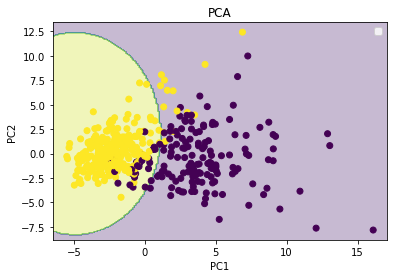

In [21]:
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_std)
gnb_pca=GaussianNB()
gnb_pca.fit(X_train_pca,y_train)

x_min, x_max=X_train_pca[:,0].min()-1,X_train_pca[:,0].max()+1
y_min, y_max=X_train_pca[:,1].min()-1,X_train_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min,x_max,200),
    np.linspace(y_min,y_max,200)
)

z=gnb_pca.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

plt.figure()
plt.contourf(xx,yy,z,alpha=0.3)
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")
plt.legend()
plt.show()